In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as scp
import uproot
import matplotlib
font = {'weight' : 'bold',
        'size'   : 15}

matplotlib.rc('font', **font)
### Opticks Nexus Analysis

import h5py
from pandas import read_hdf
import seaborn as sns
import scipy.special as misc
from scipy.special import loggamma
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize

isSafeFiles=True
SavePath="/home/argon/Projects/Ilker/CRAB_Diffusion/OpticksPaperImages"

In [5]:


def factorial(x):
    return np.math.factorial(np.uint64(x))

def Gauss1D(x,Ampl,mean,sigma):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma)**2)) 

def Poisson1D(x,gamma):
    #vfactorial=np.vectorize(factorial)
    return (gamma**x)*np.exp(-gamma)/(misc.factorial(x))

## https://stackoverflow.com/questions/53308919/overflow-error-in-poisson-distribution-implementation
## Solves overflow issue
def log_Likelihood(x,gamma):
    return (np.log(gamma)*x - loggamma(x+1)-gamma)
    #return (np.log(gamma)*x - np.log(1/(misc.factorial(x)))-gamma)

In [6]:
def Gauss1DSkew(x,Ampl,mean,sigma,a):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma+a*(x-mean))**2)) 
def FitHist1D(hist,ax,label,clr,ap):
    initials=(np.max(hist[0]),np.mean(hist[1][:-1]),np.std(hist[1][:-1]),0.5)
    fit=scp.curve_fit(Gauss1DSkew,hist[1][:-1],hist[0],p0=initials)
    String_=label+r', $\bar{X}$'+f"={round(fit[0][1],2)}," + r'$\sigma$' +f"= {abs(round(fit[0][2],2))}"
    #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
    ax.plot(hist[1][:-1],Gauss1DSkew(hist[1][:-1],*fit[0]),label=String_,color=clr,alpha=ap,linewidth=3)
    print(*fit[0])
def exp(x,A1,t1,A2,t2):
    return A1*np.exp(-x/t1)+A2*np.exp(-x/t2)
def FitExp(hist,ax,label,clr,ap):
    initials=(np.max(hist[0]),4.5,np.max(hist[0])/2,100)
    fit=scp.curve_fit(exp,hist[1][:-1],hist[0],p0=initials)
    String_=label+f",t1={abs(round(fit[0][1],2))},t2={abs(round(fit[0][3],2))}"
    #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
    ax.plot(hist[1][:-1],exp(hist[1][:-1],*fit[0]),label=String_,color=clr,alpha=ap,linewidth=3)    

In [7]:
wavelength=lambda E:1239.8/E # ev to nm 
def GetInfo(filePath):
    All={}
    subVal={}
    subsubVal={}
    f=h5py.File(filePath,"r")
    
    for folder in f:
        subVal={}
        for table in f[folder]:
            subsubVal={}
            for field in f[folder][table].dtype.fields.keys():
                subsubVal[field]=f[folder][table][field]
            subVal[table]=subsubVal
        All[folder]=subVal
    f.close()    
    return All

In [8]:
vv=GetInfo("/home/argon/Projects/Ilker/NewNexus/output/Opticks_Hit_Comparison/G4Opticks_S2_Comparison_172nm.h5")

In [9]:
if("DEBUG" in vv):
    DEBUG=vv["DEBUG"]
MC=vv["MC"]

In [10]:
if("DEBUG" in vv):
    Opticks=DEBUG['opticks_photon_info']
    
G4=MC["particles"]
OpticksHits=MC['Opticks_Hits']
G4Hits=MC["GEANT4_Optical_Hits"]
Mask=G4["particle_name"]==b'opticalphoton'
OpticksS2TimeMask=MC['Opticks_Hits']["time"]>5000
G4S2TimeMask=MC["GEANT4_Optical_Hits"]["time"]>5000
OpticksS1TimeMask=MC['Opticks_Hits']["time"]<2000
G4S1TimeMask=MC["GEANT4_Optical_Hits"]["time"]<2000



3422307.241452566 171.02015635202568 -5.504858365460046 -0.0314622566656842
3422277.3076973134 171.01559219384202 -5.505717830239166 -0.03133515164973798


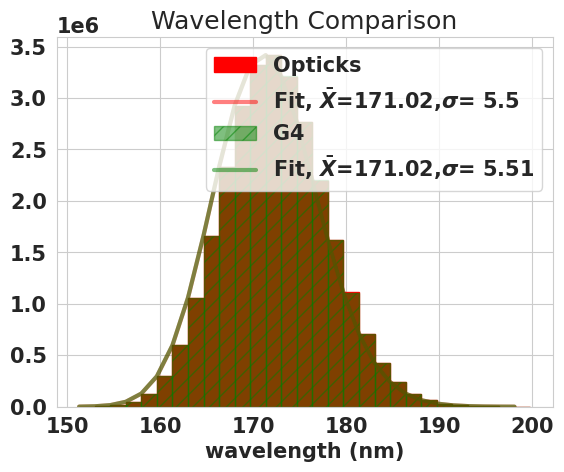

In [12]:
if("DEBUG" in vv):
    wMax=np.max(np.array([np.max(wavelength(G4["kin_energy"][Mask]*1e6)),np.max(Opticks["wavelength"])]))
    wMin=np.min(np.array([np.min(wavelength(G4["kin_energy"][Mask]*1e6)),np.min(Opticks["wavelength"])]))
    
    bins_=np.linspace(wMin,wMax,30)
    plt.title("Wavelength Comparison")
    h1=plt.hist(Opticks["wavelength"],bins=bins_,alpha=1,label="Opticks",color="red",edgecolor="red")
    FitHist1D(h1,plt,"Fit","red",0.5)
    
    h2=plt.hist(wavelength(G4["kin_energy"][Mask]*1e6),bins=bins_,alpha=0.5,label="G4",hatch='//',color="green",edgecolor="green")
    FitHist1D(h2,plt,"Fit","green",0.5)
    
    plt.xlabel("wavelength (nm)")
    plt.legend()
    if(isSafeFiles):
        plt.savefig(f"{SavePath}/S2_Timing_Absorbed.png")
    del h1,h2

In [21]:
Mask=G4["particle_name"]==b'opticalphoton'
if("DEBUG" in vv):
    OpticksPhotonTime=Opticks["time"]
G4PhotonTimeInitial=G4["initial_t"][Mask]
G4PhotonTimeFinal=G4["final_t"][Mask]

880651.2736204696 0.10183005395954478 0.00121261815678332 0.0002913692036283968
662540.7609069606 0.10348006434588752 -0.0016293222261085098 -0.000513096902805207
max 0.11062648892402649 and min 0.09650956094264984


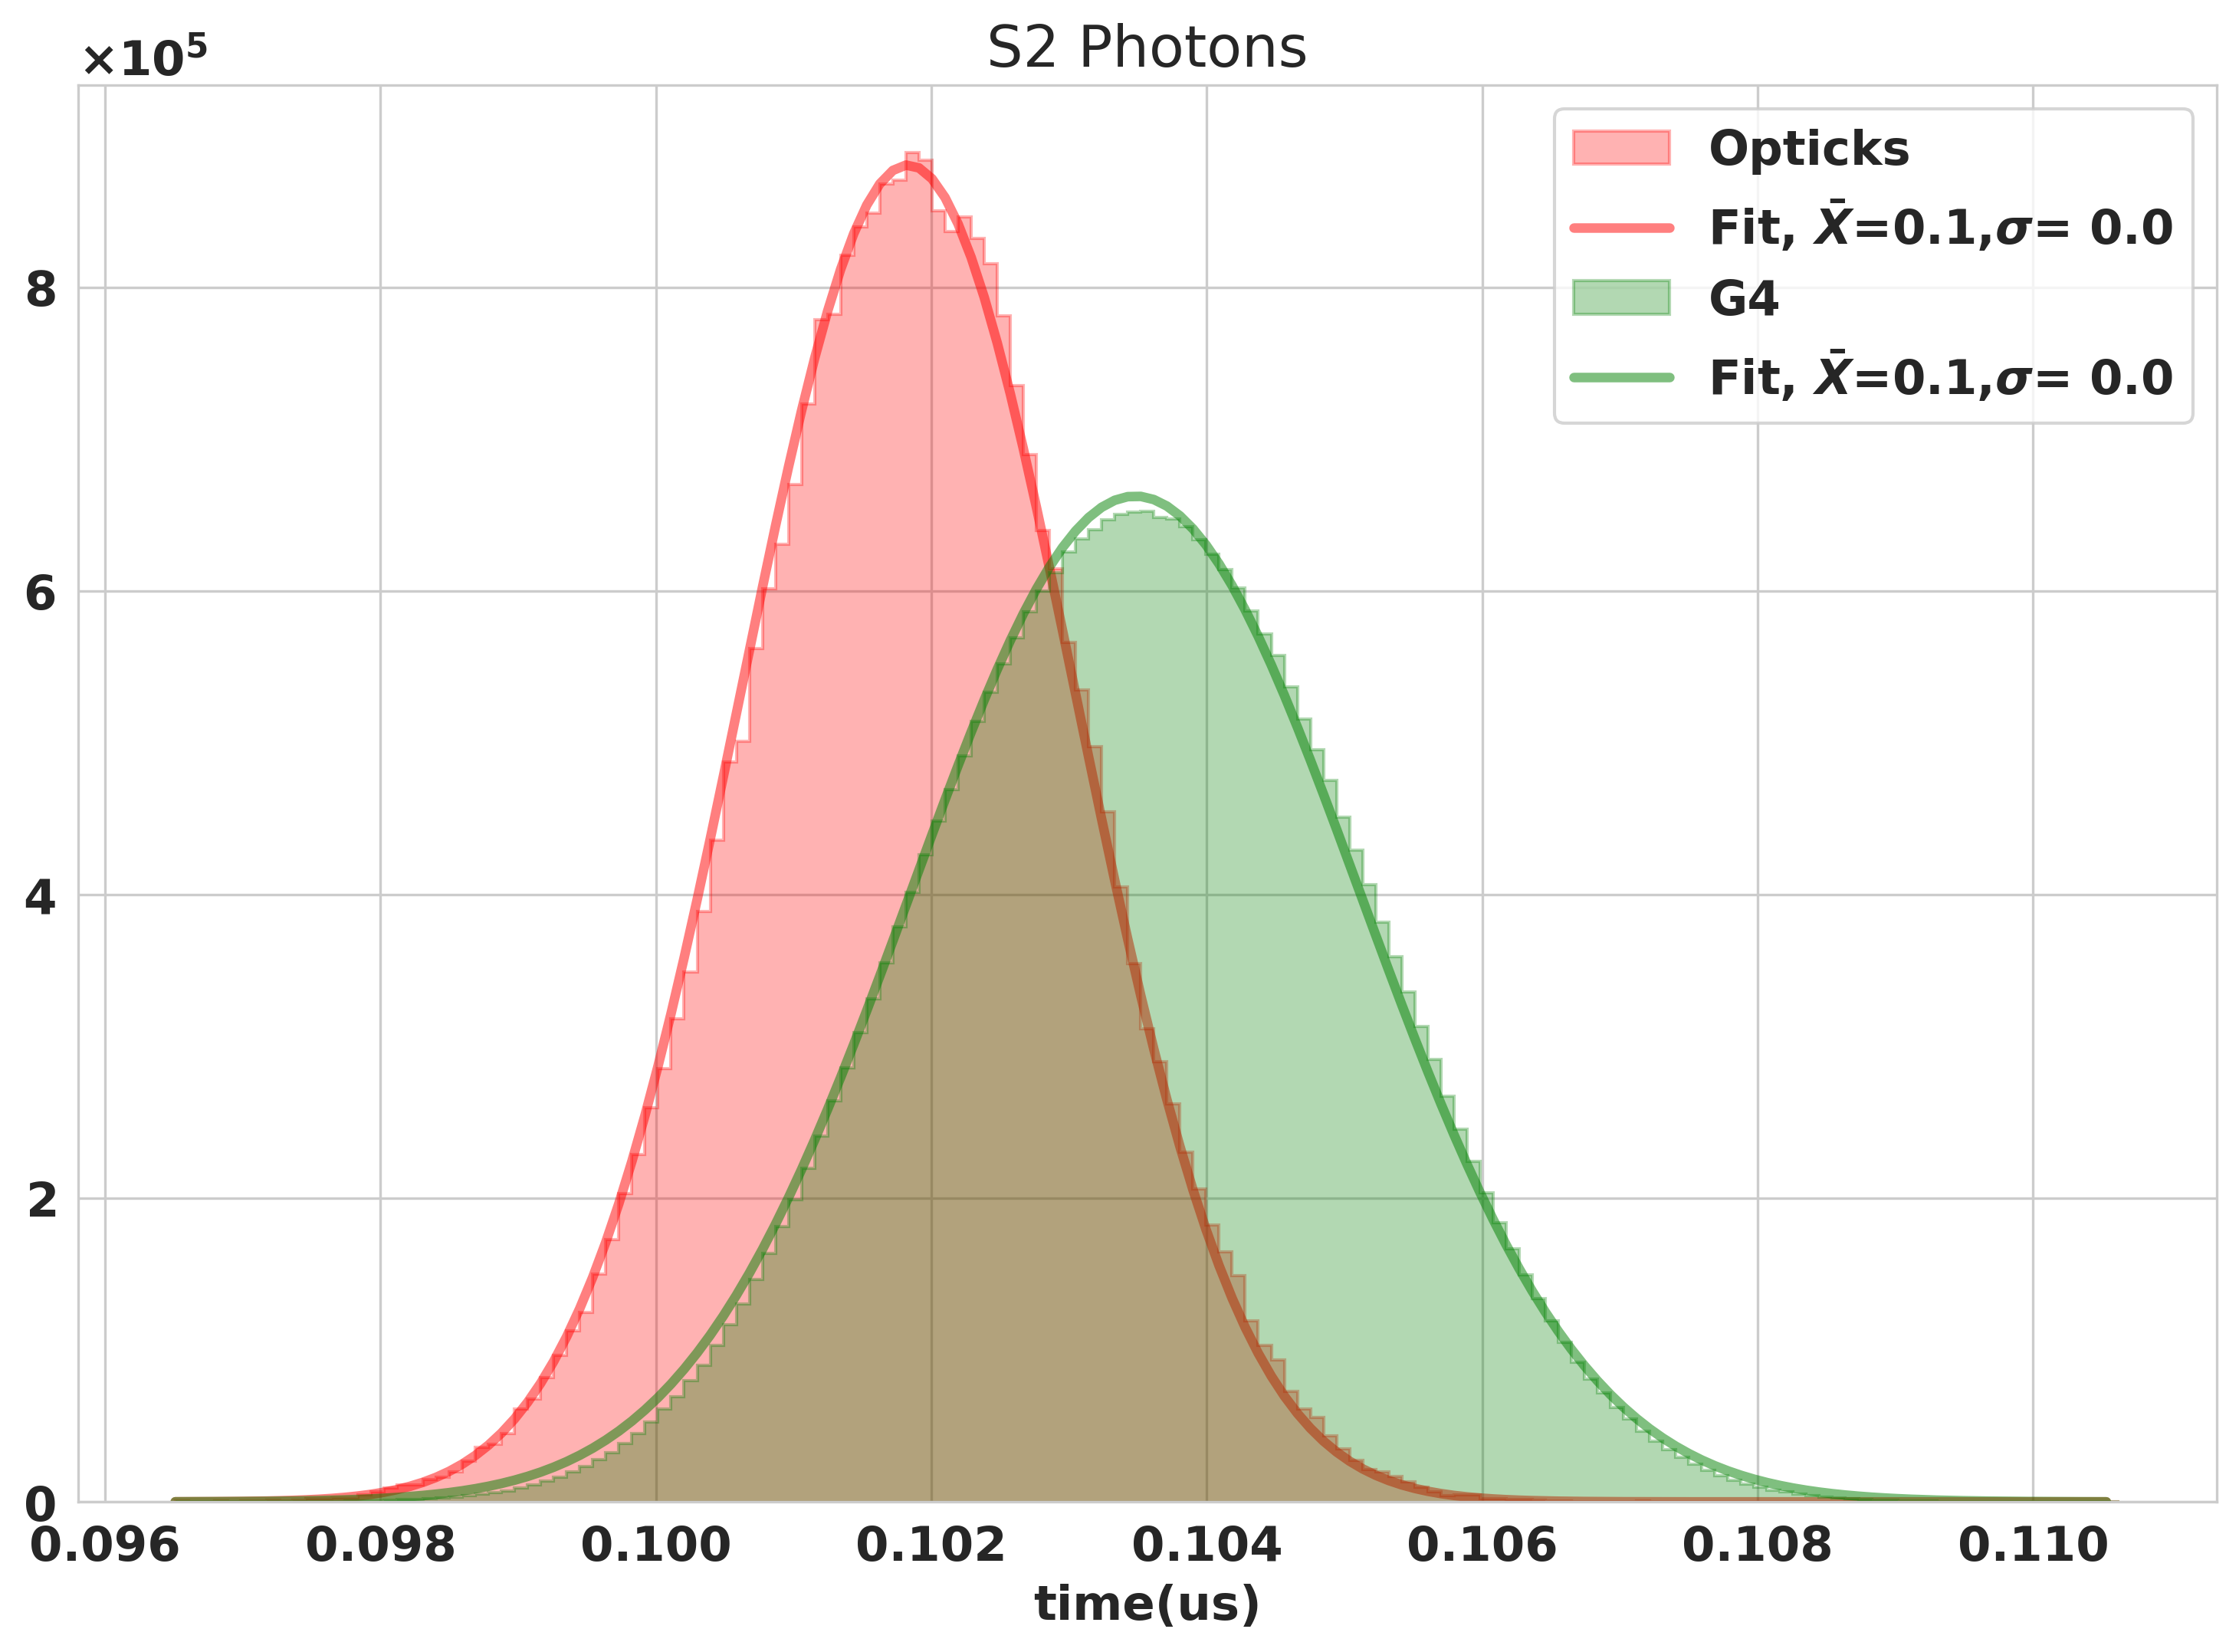

In [23]:
if("DEBUG" in vv):
    G4PhotonTimeFinal=G4PhotonTimeFinal/1000
    OpticksPhotonTime=OpticksPhotonTime/1000
    wMax=np.max(np.array([np.max(G4PhotonTimeFinal),np.max(OpticksPhotonTime)]))
    wMin=np.min(np.array([np.min(G4PhotonTimeFinal),np.min(OpticksPhotonTime)]))
    bins_=np.linspace(wMin,wMax,150)
    
    plt.figure(figsize=(12,8),dpi=300)
    plt.title("S2 Photons")
    #plt.hist(timeDifference,bins=bins_,label="G4")
    h1=plt.hist(OpticksPhotonTime,bins=bins_,alpha=0.3,label="Opticks",color="red",edgecolor="red",histtype="step",fill=True)
    FitHist1D(h1,plt,"Fit","red",0.5)
    h2=plt.hist(G4PhotonTimeFinal,bins=bins_,alpha=0.3,label="G4",histtype="step",fill=True,color="green",edgecolor="green")
    FitHist1D(h2,plt,"Fit","green",0.5)
    plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0),useMathText=True)
    #_=plt.hist(G4PhotonTimeInitial,bins=200,alpha=0.5,label="final",hatch="//")
    plt.legend()
    plt.xlabel("time(us)")
    print(f"max {wMax} and min {wMin}")
    if(isSafeFiles):
        plt.savefig(f"{SavePath}/S2_Absorbed_Time_Absorbed.png")
    del h1,h2

In [370]:
def PlotFit1D(xval,yval,ax,title,type="Gauss",bin=100,colors=["red","green"],labels=["Opticks","Geant4"],axislabels=["Frequency","Wavelength (nm)"]):
    wMax=np.max(np.array([np.max(xval),np.max(yval)]))
    wMin=np.min(np.array([np.min(xval),np.min(yval)]))
    
    bins_=np.linspace(wMin,wMax,bin)
    ax.set_title(title)
    h1=ax.hist(xval,bins=bins_,alpha=0.3,label=labels[0],color=colors[0],edgecolor=colors[0],histtype="step",fill=True)
    FitHist1D(h1,ax,"Fit",colors[0],0.5) if (type=="Gauss") else FitExp(h1,ax,"Fit",colors[0],0.5) 

    
    h2=ax.hist(yval,bins=bins_,alpha=0.3,label=labels[1],histtype="step",fill=True,color=colors[1],edgecolor=colors[1])
    FitHist1D(h2,ax,"Fit",colors[1],0.5) if (type=="Gauss") else FitExp(h2,ax,"Fit",colors[1],0.5) 
   
    ax.set_xlabel(axislabels[1])
    ax.set_ylabel(axislabels[0])
    ax.legend()
    ax.ticklabel_format(axis='y',style='sci',scilimits=(0,0),useMathText=True)
    del h1,h2
    

389.6162238878337 171.7494909174464 5.51386736488047 0.0232087090000107
343.6260687457511 171.5810855704311 5.555020500821016 0.03917223351681665
433644.2354646775 171.59766870255055 -5.484186447324743 -0.032684472572784416
411218.9913325489 171.6060904010276 -5.482796286249905 -0.03172598553043747


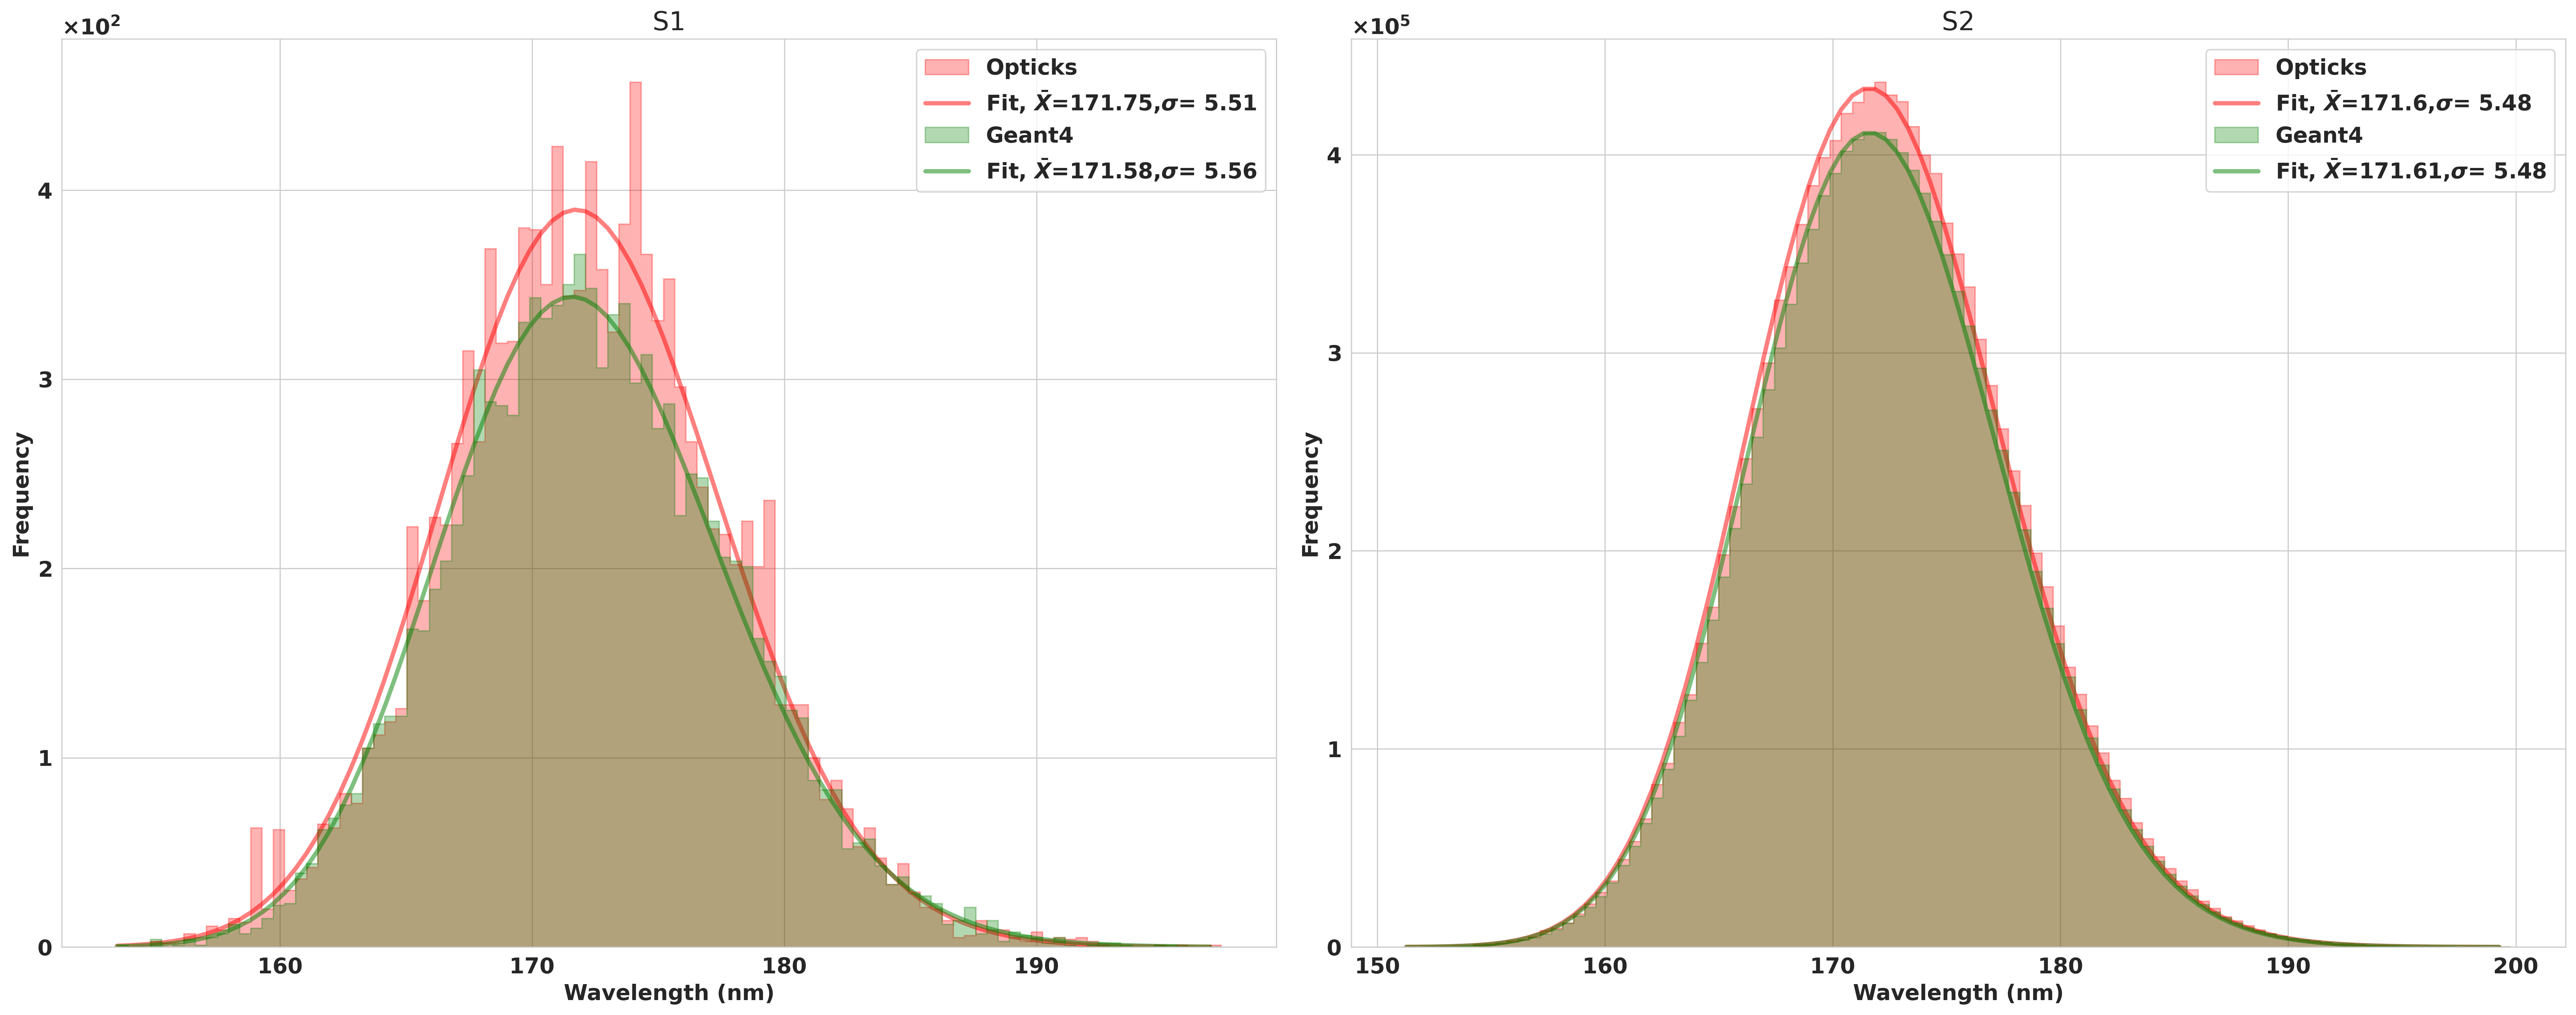

In [313]:
G4S1WavelengthHit=G4Hits["wavelength"][G4S1TimeMask]
OpticksS1WavelengthHit=OpticksHits["wavelength"][OpticksS1TimeMask]
fig,ax=plt.subplots(1,2,figsize=(25,10),dpi=300)
## Opticks Values are first for S1
PlotFit1D(OpticksS1WavelengthHit,G4S1WavelengthHit,ax[0],title="S1",bin=100)

G4S2WavelengthHit = G4Hits["wavelength"][G4S2TimeMask]
OpticksS2WavelengthHit = OpticksHits["wavelength"][OpticksS2TimeMask]

## Opticks Values are first for S1
PlotFit1D(OpticksS2WavelengthHit, G4S2WavelengthHit, ax[1], title="S2",bin=100)
fig.tight_layout()
if(isSafeFiles):
    fig.savefig(f"{SavePath}/S1_S2_Detected_Wavelength.png")


598079.096306132 102.05868208201852 1.5486905043422736 0.0019515182060721784
470240.3422575147 103.7287231646689 -1.8769842698223222 0.0009491220310756088


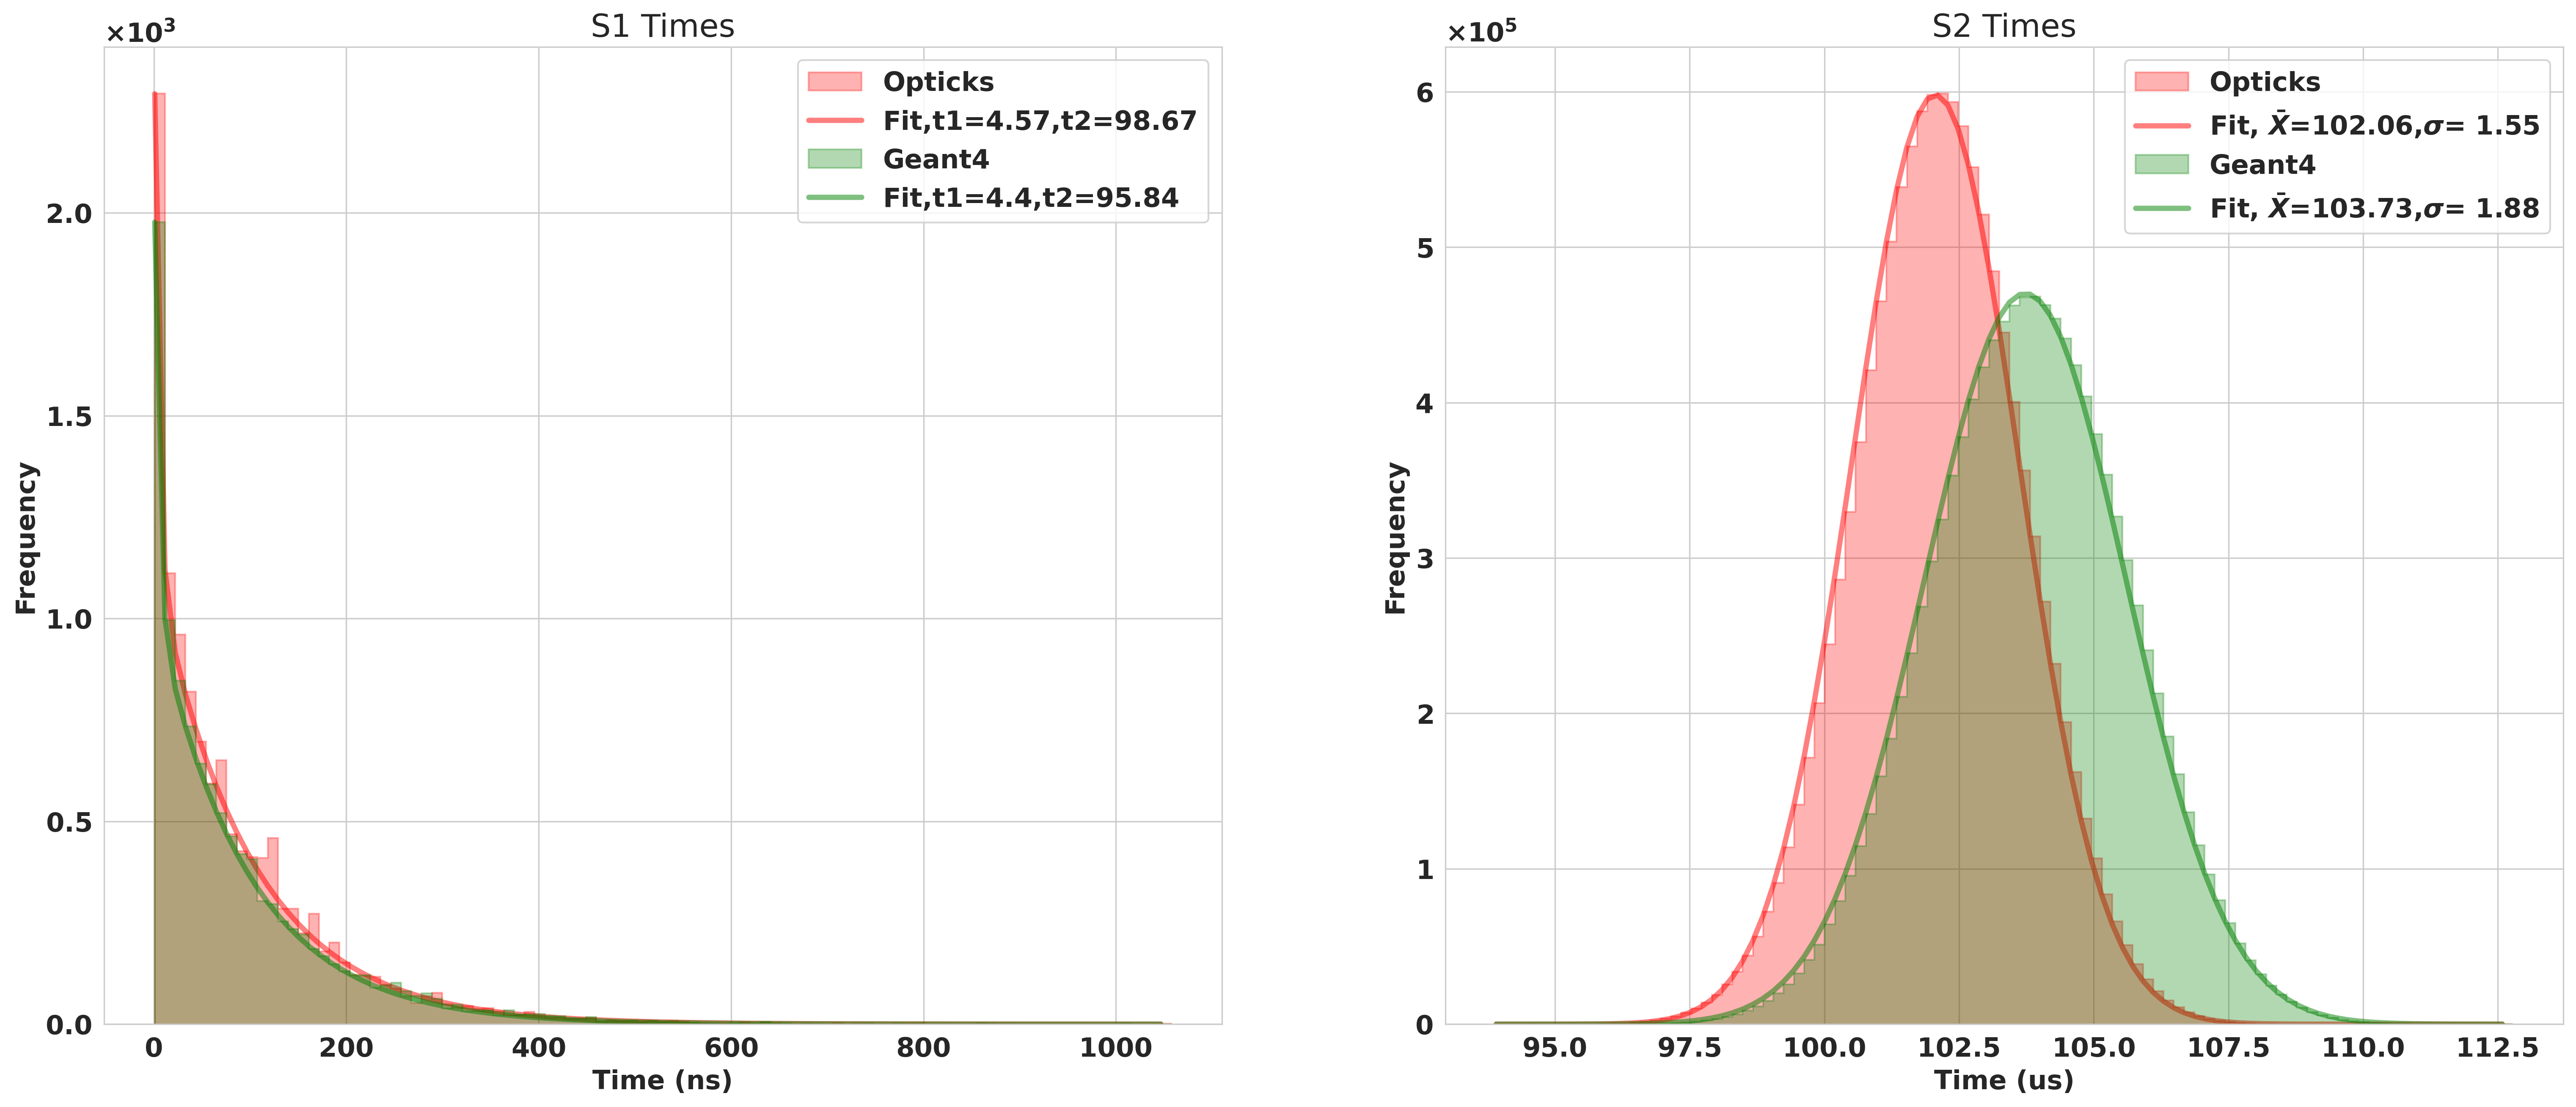

In [314]:
G4S1TimeHit=G4Hits["time"][G4S1TimeMask]
OpticksS1TimeHit=OpticksHits["time"][OpticksS1TimeMask]
fig,ax=plt.subplots(1,2,figsize=(25,10),dpi=300)
S1Lables=["Frequency","Time (ns)"]
S2Lables=["Frequency","Time (us)"]

## Opticks Values are first for S1
PlotFit1D(OpticksS1TimeHit,G4S1TimeHit,ax[0],type="Exp",title="S1 Times",axislabels=S1Lables,bin=100)

G4S2TimeHit = G4Hits["time"][G4S2TimeMask]
OpticksS2TimeHit = OpticksHits["time"][OpticksS2TimeMask]

## Opticks Values are first for S1
PlotFit1D(OpticksS2TimeHit/1000, G4S2TimeHit/1000, ax[1],axislabels=S2Lables, title="S2 Times",bin=100)

if(isSafeFiles):
    fig.savefig(f"{SavePath}/S1_S2_Detected_Times.png")


In [315]:
OpticksHits['boundary']

array([29, 29, 29, ..., 29, 29, 29], dtype=uint32)

In [316]:
## Opticks
OpticsS1PMTMask=(OpticksHits['z'][OpticksS1TimeMask]<100)    ##PMT
OpticksS1CamMask=(OpticksHits['z'][OpticksS1TimeMask] > 200)
## Opticks
OpticsS2PMTMask = (OpticksHits['z'][OpticksS2TimeMask] < 100)  ##PMT
OpticksS2CamMask = (OpticksHits['z'][OpticksS2TimeMask] > 200)  ##Camera
bnd = [np.unique(OpticksHits['boundary'][OpticksS2TimeMask][OpticsS2PMTMask]), np.unique(OpticksHits['boundary'][OpticksS2TimeMask][OpticksS2CamMask])]

print(bnd)
if (len(bnd[0]) > 1 or len(bnd[1]) > 1):
    print("Boundary issue ")
    bnd = [bnd[0], bnd[1]]

## Geant4
Geant4S2PMTMask = G4Hits['name'][G4S2TimeMask] == b'PMTWindow'  ##PMT
Geant4S2CamMask = G4Hits['name'][G4S2TimeMask] == b'camWindow'  ##Camera

Geant4S1PMTMask = G4Hits['name'][G4S1TimeMask] == b'PMTWindow'  ##PMT
Geant4S1CamMask = G4Hits['name'][G4S1TimeMask] == b'camWindow'  ##Camera##Camera


[array([29], dtype=uint32), array([27], dtype=uint32)]


In [357]:
def Plot2D_JointPlot(valO,ValG4,FileName,Title,Binsize=200,isPlottext=False):

    maXX=np.max(np.array([np.max(ValG4[0]),np.max(valO[0])]))
    miNX=np.min(np.array([np.min(ValG4[0]),np.min(valO[0])]))
    lins1X=np.linspace(miNX,maXX,Binsize)
    
    maXY=np.max(np.array([np.max(ValG4[1]),np.max(valO[1])]))
    miNY=np.min(np.array([np.min(ValG4[1]),np.min(valO[1])]))
    lins1Y=np.linspace(miNY,maXY,Binsize)
    
    G4Dict={"x(mm)":ValG4[0],"y(mm)":ValG4[1]}
    OpticksDict={"x(mm)":valO[0],"y(mm)":valO[1]}
    plt.figure(figsize=(15,15),dpi=300)
    g=sns.jointplot(data=G4Dict,x="x(mm)", y="y(mm)", kind='hist',marginal_kws={"bins":Binsize,"kde":True},cmap="viridis",color="green",height=10,cbar=True,cbar_kws={"use_gridspec":False, "location":"top","aspect":50,"fraction":0.016,"pad":0,"aspect":50});
    plt.hist2d(ValG4[0], ValG4[1], bins=[lins1X,lins1Y], cmap="viridis");
    if(isPlottext):
        x_mean = round(np.mean(ValG4[0]),2)
        x_std = round(np.std(ValG4[0]),2)
        g.ax_marg_x.axvspan(x_mean - x_std, x_mean + x_std, color='gray', alpha=0.35)

        y_mean = round(np.mean(ValG4[1]),2)
        y_std = round(np.std(ValG4[1]),2)
        g.ax_marg_y.axhspan(y_mean - y_std, y_mean + y_std, color='gray', alpha=0.35)
        g.refline(x=x_mean, y=y_mean, color='green', ls='--',alpha=0.4)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        print(x_mean,x_std)
        labelX_str=r'$\bar{X}$' + f" = {str(x_mean)}, " + r'$\sigma_{X}$'+f" = {str(x_std)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(y_mean)}, \n " + r'$\sigma_{Y}$'+f" = {str(y_std)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(x_mean + 2*x_std, np.mean(Ydata), labelX_str, fontsize=12)
        ax_marg_y.text( np.mean(Xdata),y_mean + 2*y_std, labelY_str, fontsize=12)
        
    
    #g.plot_joint(sns.kdeplot, color="red", zorder=0, alpha=0.3,levels=6)
    #g.plot_marginals(sns.rugplot,  color="red", height=+.02, clip_on=False)
    plt.suptitle(Title[1],fontweight="bold",ha="left",size="medium")
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[1]}.png")
        
    g=sns.jointplot(data=OpticksDict,x="x(mm)",y= "y(mm)" ,kind='hist',cmap="viridis",marginal_kws={"bins":Binsize,"kde":True},color="red",height=10,cbar=True,cbar_kws={"use_gridspec":True,"fraction":0.016,"pad":0,"location":"top","aspect":50});

    #g.plot_joint(sns.kdeplot,  color="green",alpha=0.3, zorder=0, levels=6)
    #g.plot_marginals(sns.rugplot,  color="green", height=+.02, clip_on=False)
    plt.hist2d(valO[0], valO[1], bins=[lins1X,lins1Y], cmap="viridis");
    if(isPlottext):
        x_mean = round(np.mean(valO[0]),2)
        x_std = round(np.std(valO[0]),2)
        g.ax_marg_x.axvspan(x_mean - x_std, x_mean + x_std, color='gray', alpha=0.35)
    
        y_mean = round(np.mean(valO[1]),2)
        y_std = round(np.std(valO[1]),2)
        g.ax_marg_y.axhspan(y_mean - y_std, y_mean + y_std, color='gray', alpha=0.35)
        g.refline(x=x_mean, y=y_mean, color='red', ls='--',alpha=0.3)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        print(x_mean,x_std)
        labelX_str=r'$\bar{X}$' + f" = {str(x_mean)}, "+ r'$\sigma_{X}$'+f" = {str(x_std)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(y_mean)}, \n " + r'$\sigma_{Y}$'+f" = {str(y_std)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(x_mean + 2*x_std, np.mean(Ydata), labelX_str, fontsize=12)
        ax_marg_y.text( np.mean(Xdata),y_mean + 2*y_std, labelY_str, fontsize=12)
    
    plt.suptitle(Title[0],fontweight="bold",ha="left",size="medium")
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")

<Figure size 4500x4500 with 0 Axes>

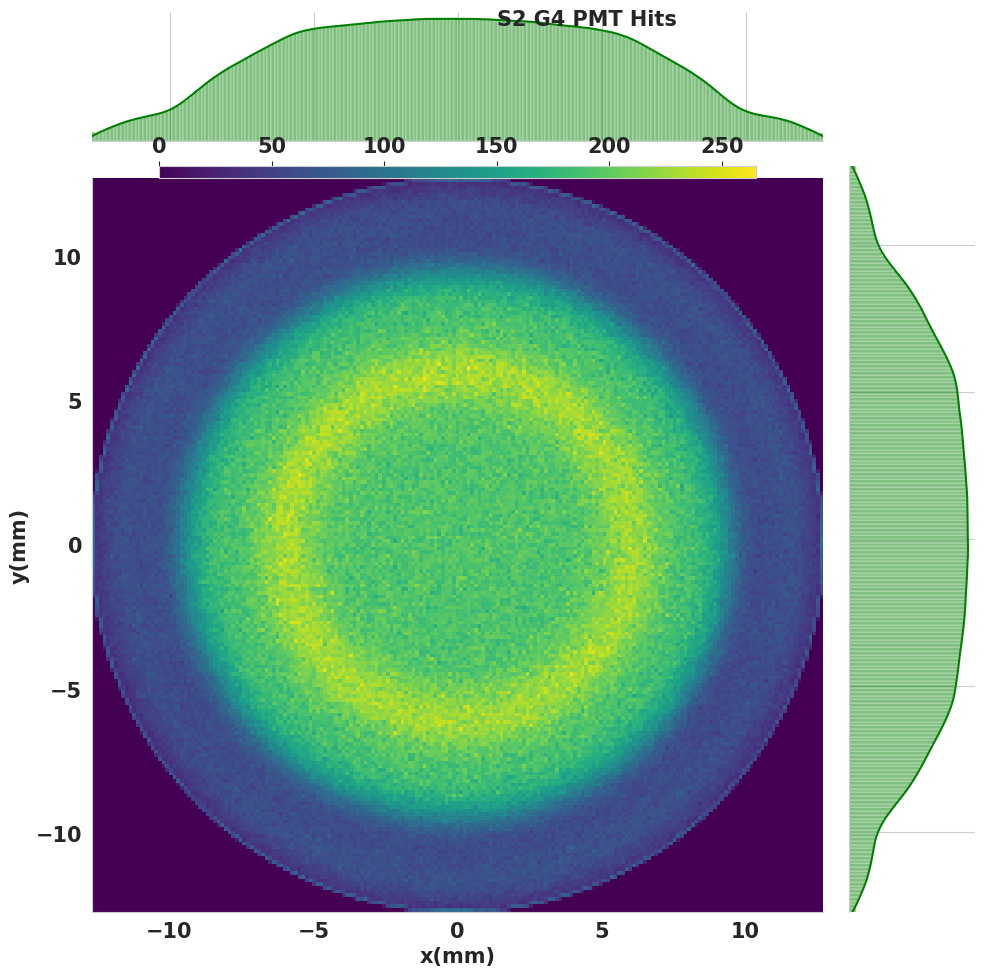

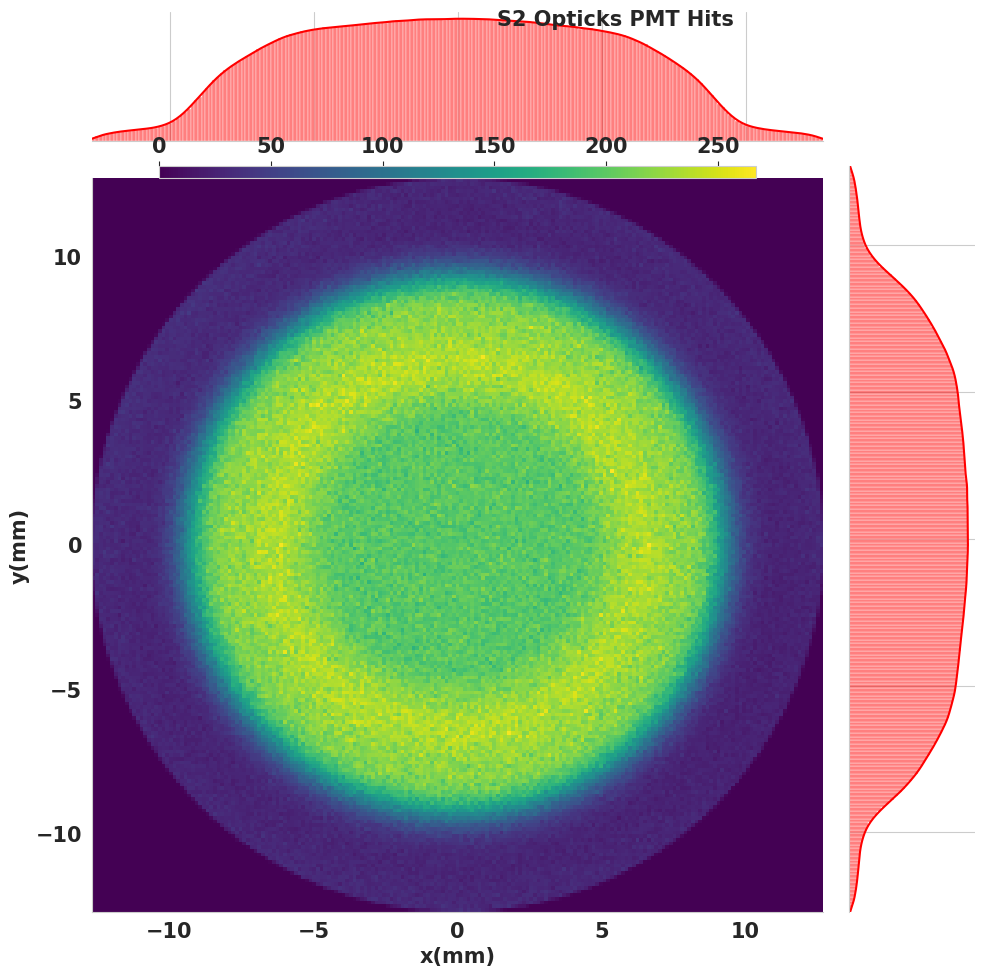

In [318]:
### Get S2 PMT Comparison
G4X=G4Hits["x"][G4S2TimeMask][Geant4S2PMTMask]
G4Y=G4Hits["y"][G4S2TimeMask][Geant4S2PMTMask]
OX=OpticksHits['x'][OpticksS2TimeMask][OpticsS2PMTMask]
OY=OpticksHits['y'][OpticksS2TimeMask][OpticsS2PMTMask]
Plot2D_JointPlot([OX,OY],[G4X,G4Y],["S2_Opticks_PMT_Hits","S2_G4_PMT_Hits"],["S2 Opticks PMT Hits","S2 G4 PMT Hits"])

<Figure size 4500x4500 with 0 Axes>

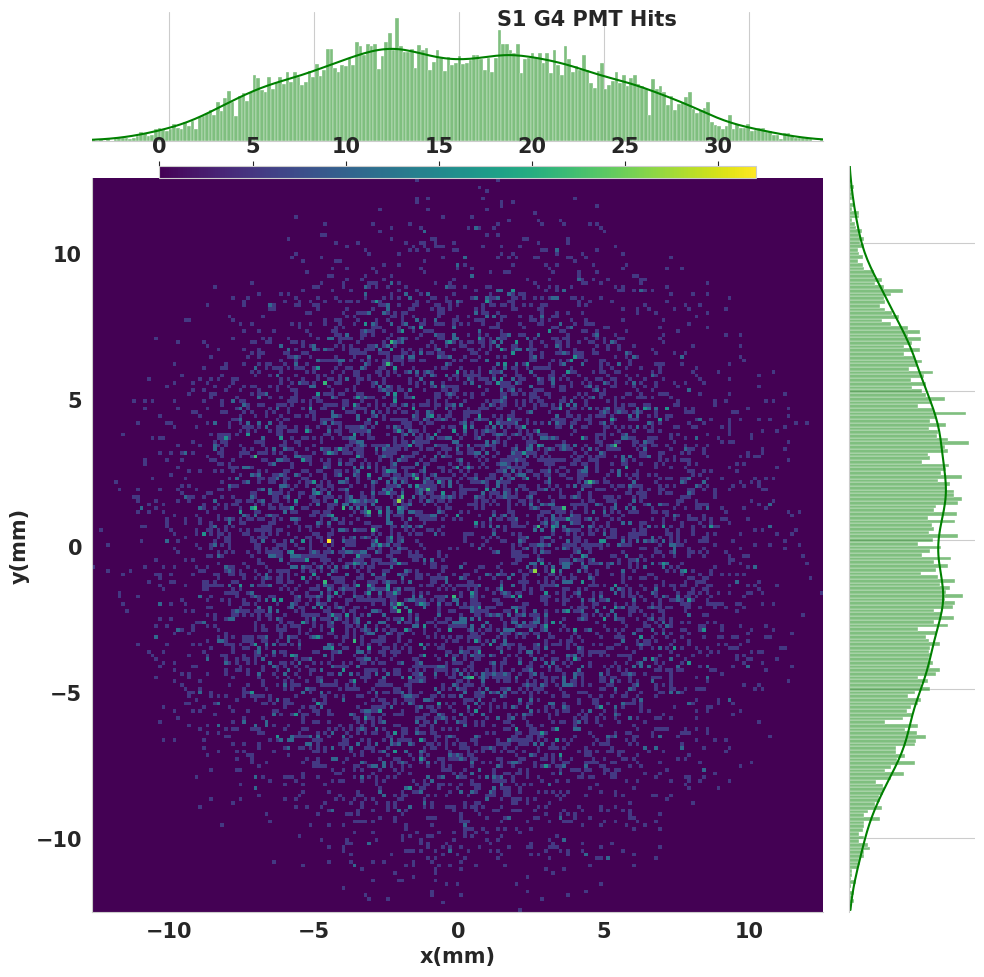

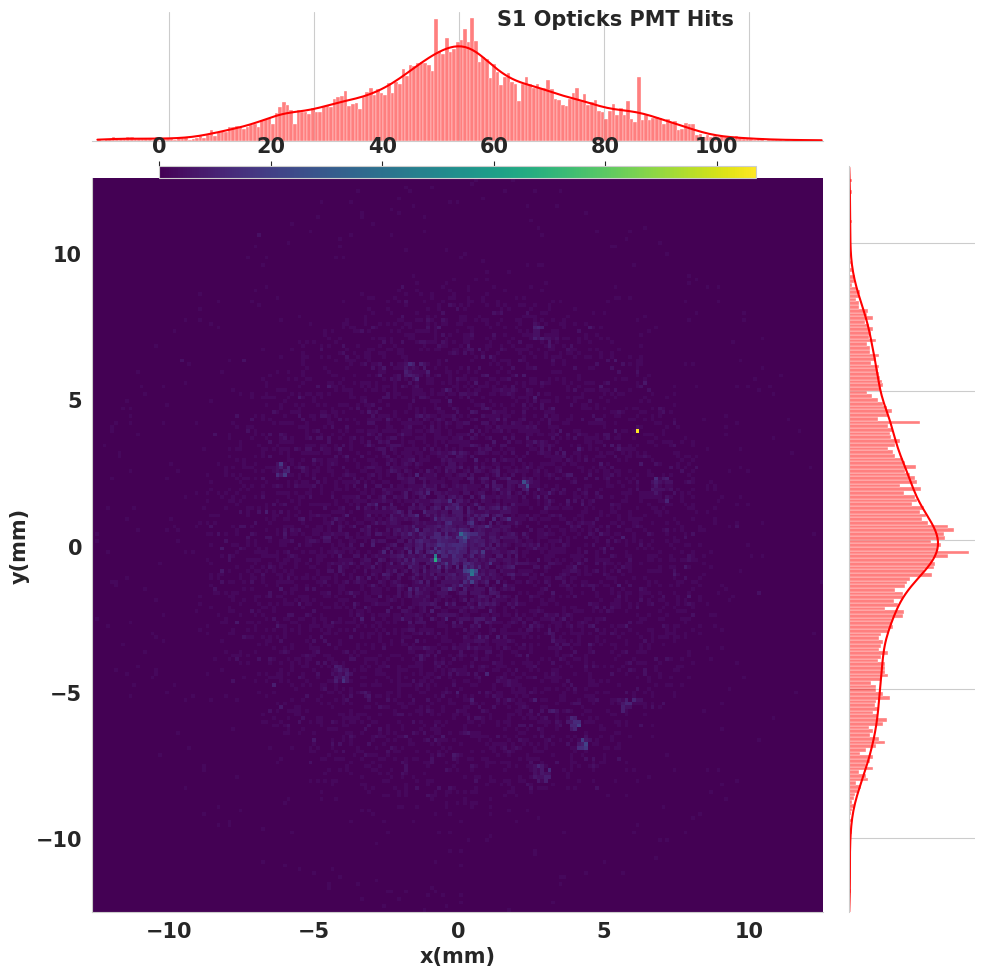

In [319]:
### Get S2 PMT Comparison
G4X=G4Hits["x"][G4S1TimeMask][Geant4S1PMTMask]
G4Y=G4Hits["y"][G4S1TimeMask][Geant4S1PMTMask]
OX=OpticksHits['x'][OpticksS1TimeMask][OpticsS1PMTMask]
OY=OpticksHits['y'][OpticksS1TimeMask][OpticsS1PMTMask]
Plot2D_JointPlot([OX,OY],[G4X,G4Y],["S1_Opticks_PMT_Hits","S1_G4_PMT_Hits"],["S1 Opticks PMT Hits","S1 G4 PMT Hits"])

-0.04 1.22
-0.29 3.19


<Figure size 4500x4500 with 0 Axes>

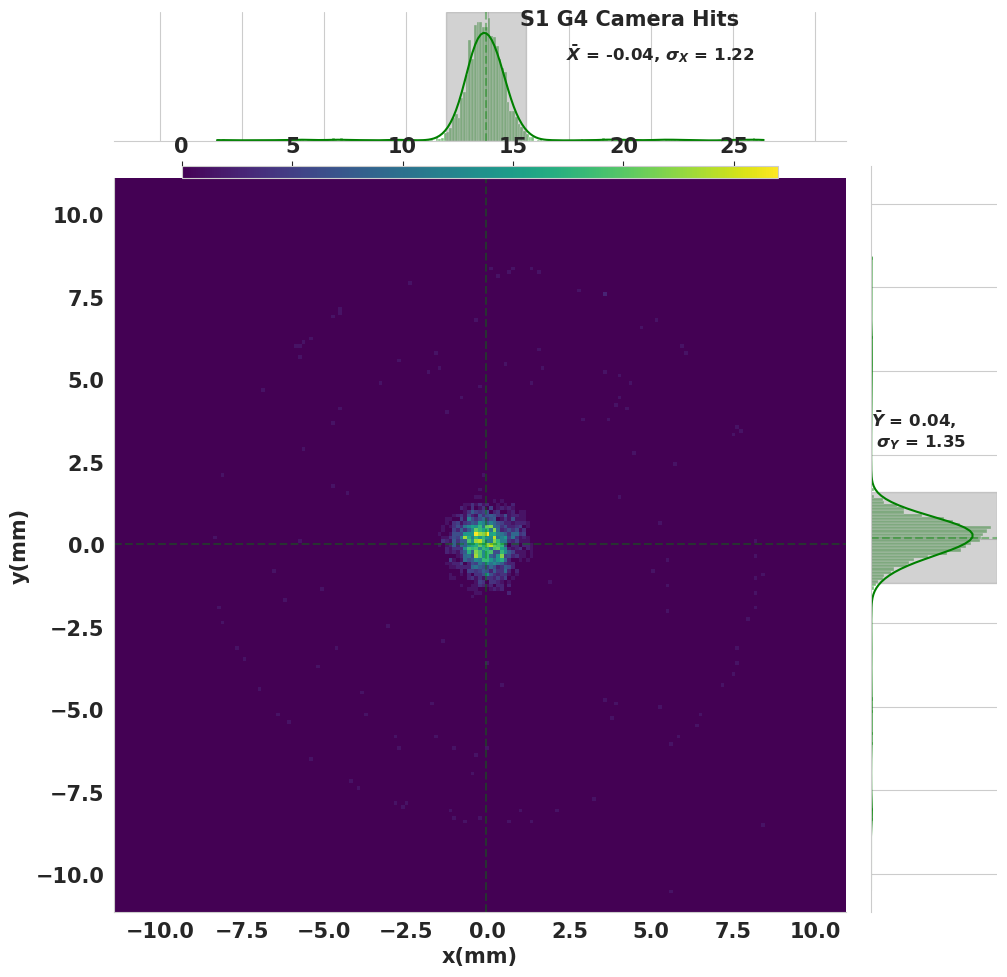

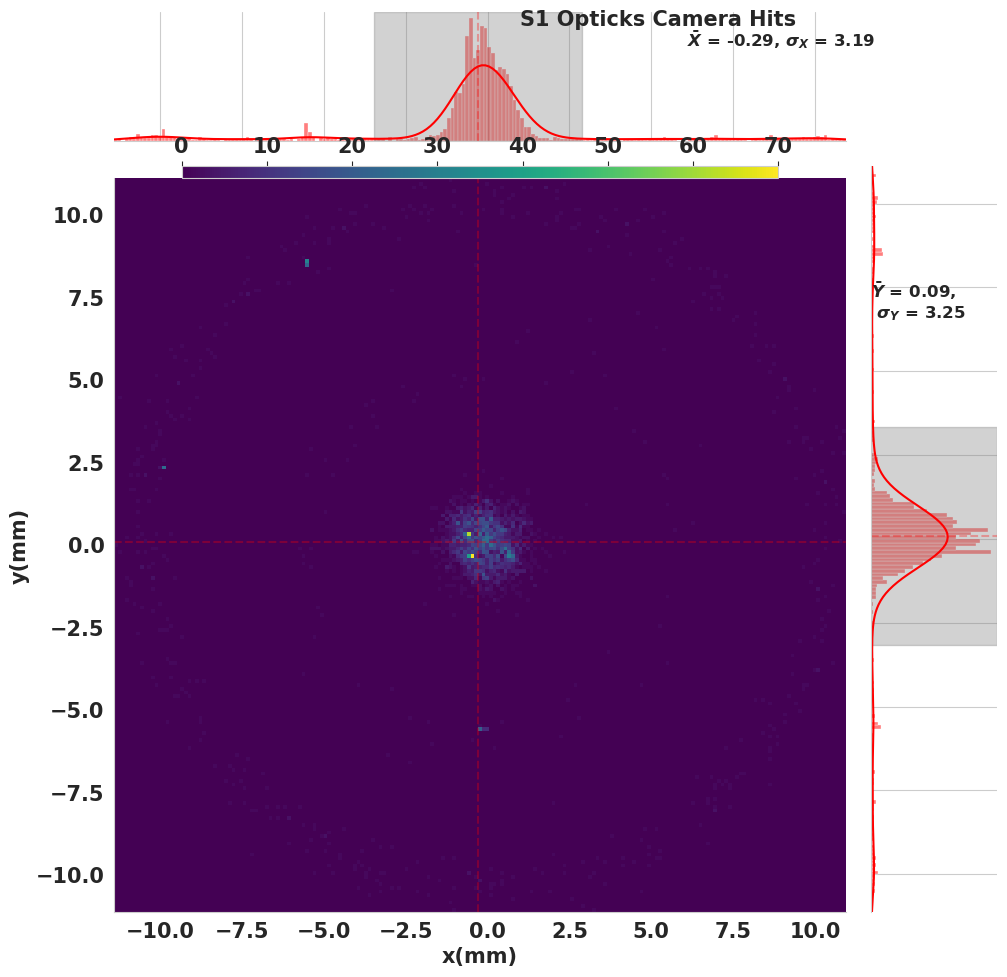

In [358]:
### Get S1 Camera Comparison
G4X=G4Hits["x"][G4S1TimeMask][Geant4S1CamMask]
G4Y=G4Hits["y"][G4S1TimeMask][Geant4S1CamMask]
OX=OpticksHits['x'][OpticksS1TimeMask][OpticksS1CamMask]
OY=OpticksHits['y'][OpticksS1TimeMask][OpticksS1CamMask]
Plot2D_JointPlot([OX,OY],[G4X,G4Y],["S1_Opticks_Camera_Hits","S1_G4_Camera_Hits"],["S1 Opticks Camera Hits","S1 G4 Camera Hits"],isPlottext=True)

-0.05 1.06
-0.05 1.31


<Figure size 4500x4500 with 0 Axes>

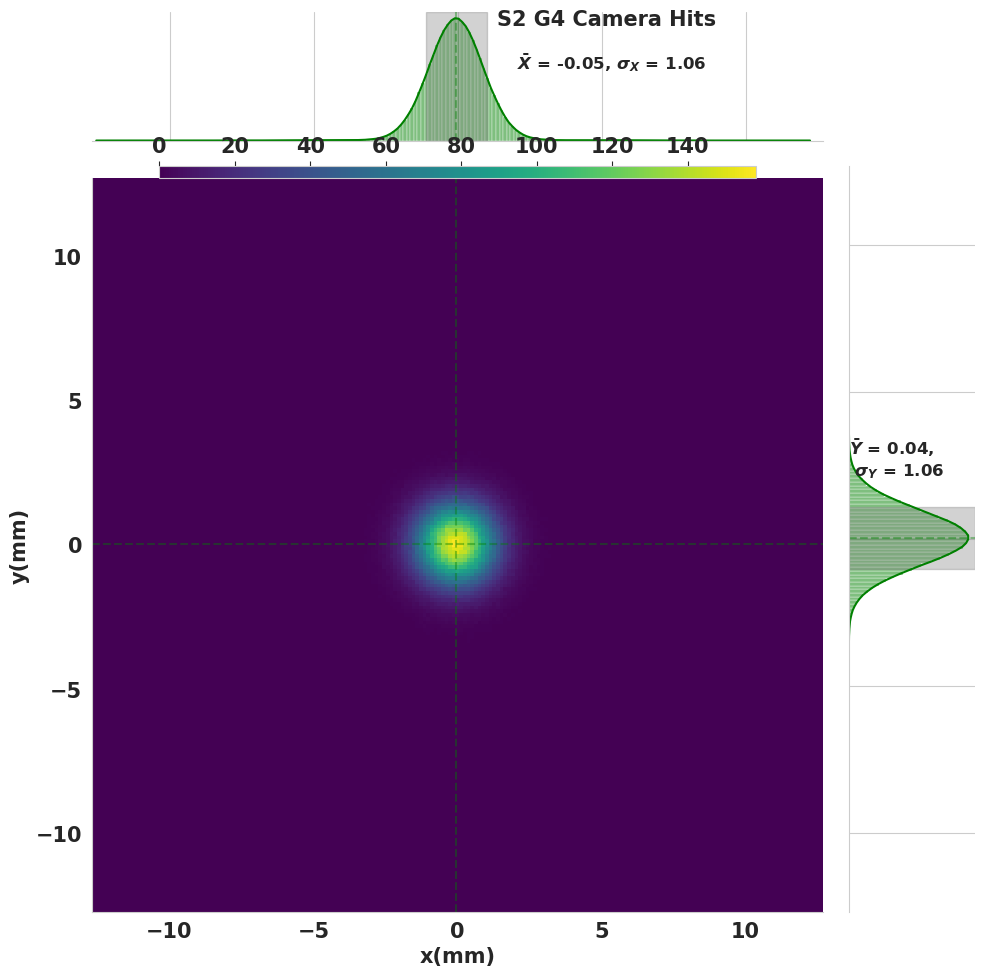

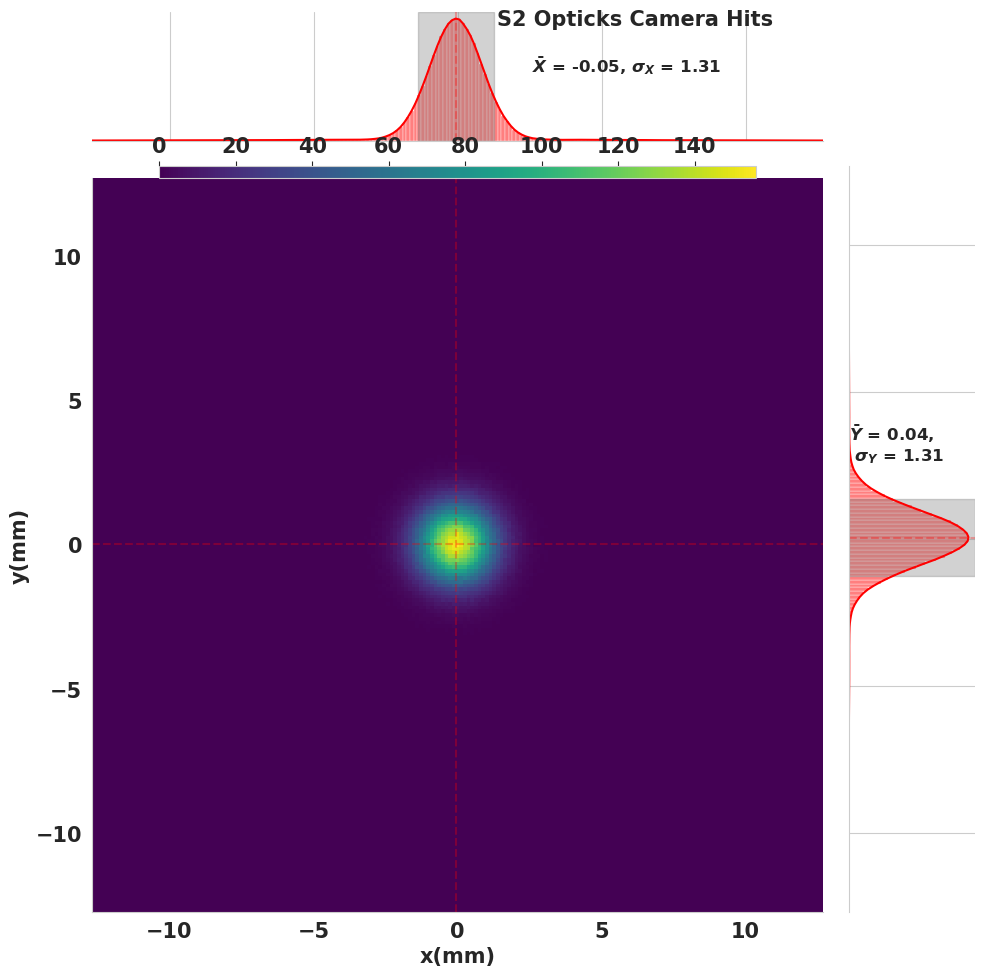

In [359]:
### Get S2 PMT Comparison
G4X=G4Hits["x"][G4S2TimeMask][Geant4S2CamMask]
G4Y=G4Hits["y"][G4S2TimeMask][Geant4S2CamMask]
OX=OpticksHits['x'][OpticksS2TimeMask][OpticksS2CamMask]
OY=OpticksHits['y'][OpticksS2TimeMask][OpticksS2CamMask]
Plot2D_JointPlot([OX,OY],[G4X,G4Y],["S2_Opticks_Camera_Hits","S2_G4_Camera_Hits"],["S2 Opticks Camera Hits","S2 G4 Camera Hits"],isPlottext=True)

In [348]:
def getHits(Hits,mask1,mask2):
    if(len(mask1) >1 and len(mask2)>1):
        unique, counts = np.unique(Hits['event_id'][mask1][mask2], return_counts=True)
    elif(len(mask1) >1 and len(mask1) <1):
        unique, counts = np.unique(Hits['event_id'][mask1], return_counts=True)
    return counts
def pltHits(O,G4,ax,Labels,Binsize=30):
    maXX=np.max(np.array([np.max(G4),np.max(O)]))
    miNX=np.min(np.array([np.min(G4),np.min(O)]))
    lins1X=np.linspace(miNX,maXX,Binsize)
    ax.set_title(Labels)
    h1=ax.hist(G4,bins=lins1X,label=f"G4_"+Labels,color="green",alpha=0.3,edgecolor="green",histtype="step",fill=True)
    FitHist1D(h1,ax,"Fit","green",0.6)
    
    h2=ax.hist(O,bins=lins1X,label="Opticks_"+Labels,alpha=0.3,color="red",edgecolor="red",histtype="step",fill=True)
    FitHist1D(h2,ax,"Fit","red",0.6)
    ax.set_xlabel("Photons Detected")
    ax.legend()
    del h1,h2

6.2807307697400905 24278.51228769303 169.51502366222175 0.08027829338324205
10.03604060419456 24613.681030968804 106.15426899198724 -0.055825427452668726
18.30857219253385 206513.5176066808 -888.4542723163454 -0.0611683851747576
27.270712711255264 219138.72581574906 -611.929867012988 -0.22490342348944678
6.351304229320952 45.00842120493079 8.48007166146826 0.008918659673575862
5.936196570476521 56.279460360111635 8.168452655157445 0.07050518207797028
8.583693253061057 168.69373563037462 9.170681824082688 -0.03235821915142398
7.46675375001252 190.44834291300486 9.222008114104446 -0.2591190657109871


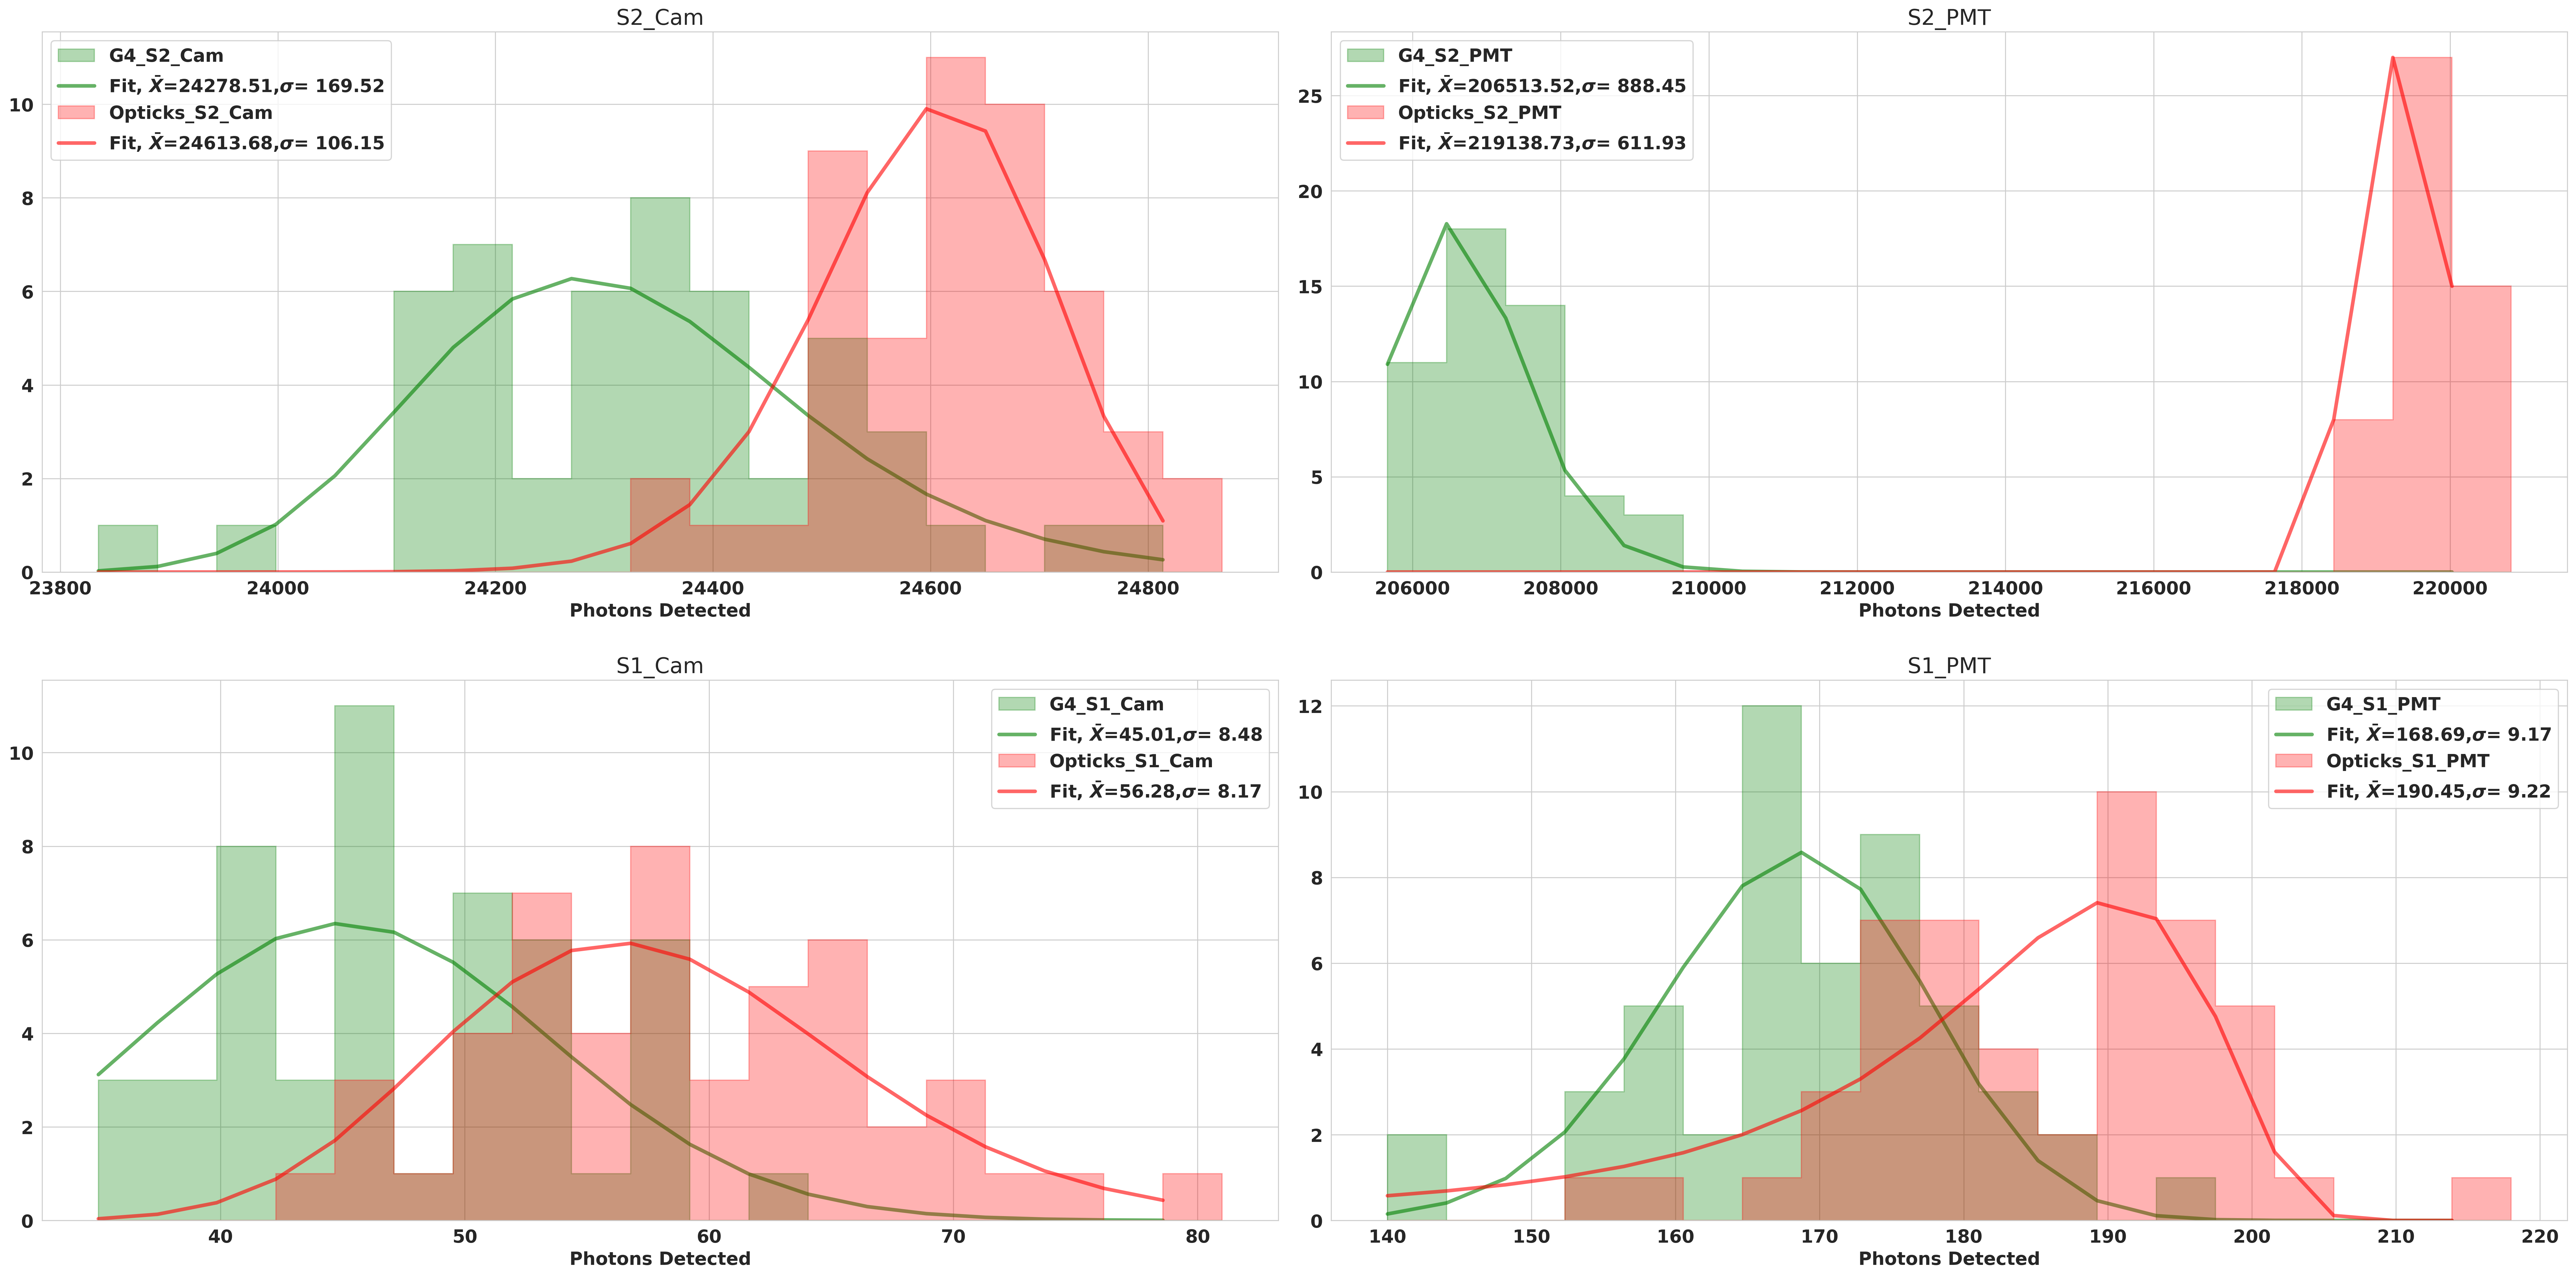

In [349]:
Binsize=20
fig,ax=plt.subplots(2,2,figsize=(30,15),dpi=300)
G4S2_Cam=getHits(G4Hits,G4S2TimeMask,Geant4S2CamMask)
OS2_Cam=getHits(OpticksHits,OpticksS2TimeMask,OpticksS2CamMask)
pltHits(OS2_Cam,G4S2_Cam,ax=ax[0,0],Labels="S2_Cam",Binsize=Binsize)
G4S2_PMT=getHits(G4Hits,G4S2TimeMask,Geant4S2PMTMask)
OS2_PMT=getHits(OpticksHits,OpticksS2TimeMask,OpticsS2PMTMask)
pltHits(OS2_PMT,G4S2_PMT,ax=ax[0,1],Labels="S2_PMT",Binsize=Binsize)
G4S1_Cam = getHits(G4Hits, G4S1TimeMask, Geant4S1CamMask)
OS1_Cam = getHits(OpticksHits, OpticksS1TimeMask, OpticksS1CamMask)
pltHits(OS1_Cam, G4S1_Cam, ax=ax[1, 0],Labels="S1_Cam",Binsize=Binsize)
G4S1_PMT = getHits(G4Hits, G4S1TimeMask, Geant4S1PMTMask)
OS1_PMT = getHits(OpticksHits, OpticksS1TimeMask, OpticsS1PMTMask)

pltHits(OS1_PMT, G4S1_PMT, ax=ax[1, 1],Labels="S1_PMT",Binsize=Binsize)
if(isSafeFiles):
    fig.savefig(f"{SavePath}/Hits.png")
fig.tight_layout()
fig.subplots_adjust(hspace=0.2)
plt.show()